# Fault/non-fault counts + Method 2: synthetic-only concept-drift check

- Count fault-related (class 1) vs non-fault-related (class 0/-1) triangles in the
  synthetic dataset, before and after the quality filter.
- Check if **Method 2** contibutes to the synthetic domain. The class condition

  $$\forall\, i, j \in M \quad P(Y \mid Z, D{=}S, M{=}i) \approx P(Y \mid Z, D{=}S, M{=}j)$$

  is checked twice with the same flow: with `Z` from **Method 2** (an independent `StandardScaler`
  fit per simulation/file) and with `Z` from a global scale (one `StandardScaler` fit on
  the training surfaces; **Method 1** and **Method 3** are the same on synthetic data).
  `Y` = `Fault` (`1` = fault-related, `0`/`-1` = non-fault-related), `D` is domain = {`S` - synthetic,
  `R` - real} and `M` = `File_number` (`0..999`).

Preprocessing is a 1:1 replica of preprocessing applied in every experiment.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import binomtest, spearmanr
from sklearn.metrics import roc_auc_score

# Utils created for the experiments.
from ss_preprocessing_utils import (
    SORTING_PAIRS,
    SYNTHETIC_PASSTHROUGH_COLS,
    build_sorted_features,
    filter_triangles,
    grouped_cv_fault_counts_by_scaling_method,
    load_raw_synthetic,
    method2_scale_per_group,
    sort_values,
)

## Paths and Config

In [2]:
# Here insert the path to the dataset.
INPUT_PATH = r"../../SubsurfaceBreaks-main/Broken_terrains_datasets"

# Config.
N_SYNTHETIC_FILES = 1000
RANDOM_STATE = 42
N_SPLITS = 10
ALPHA = 0.05

# Helper constants.
MODEL_LABELS = {"logistic_regression": "Logistic regression", "random_forest": "Random forest"}
METHOD_LABELS = {"method3": "global scale", "method2": "Method 2"}

FAULT_LABELS = {1: "fault (class 1)", -1: "non-fault (class 0)"}
CLASS_ORDER = ("fault (class 1)", "non-fault (class 0)")


pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

In [3]:
# Will create figures (relative path to the notebook).
FIG_OUT_DIR = Path("method2_synthetic_concept_drift")
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

def _save_svg(fig, file_name: str) -> None:
    """Save a figure as an SVG file."""
    fig.savefig(
        FIG_OUT_DIR / f"{file_name}.svg",
        format="svg",
        bbox_inches="tight",
        facecolor="white",
        dpi=1200,
    )

## Preprocessing flow

In [4]:
# Synthetic data preprocessing pipeline.
raw_df = load_raw_synthetic(INPUT_PATH, n_files=N_SYNTHETIC_FILES)
filtered_df = filter_triangles(raw_df)

sorted_df = build_sorted_features(
    filtered_df,
    SORTING_PAIRS,
    sort_values,
    passthrough_cols=SYNTHETIC_PASSTHROUGH_COLS,
)
sorted_df = pd.concat(
    [sorted_df, filtered_df[["File_number", "Fault"]].reset_index(drop=True)],
    axis=1,
)

feature_cols = sorted_df.drop(columns=["Fault", "File_number"]).columns.tolist()

print(f"raw_df:      {raw_df.shape}")
print(f"filtered_df: {filtered_df.shape}")
print(f"sorted_df:   {sorted_df.shape}")
print(f"n features:  {len(feature_cols)}")
print(feature_cols)

raw_df:      (185980, 62)
filtered_df: (145297, 62)
sorted_df:   (145297, 26)
n features:  24
['X_N', 'Y_N', 'Z_N', 'X_D', 'Y_D', 'Z_D', 'Euclidean_N_Max', 'Euclidean_N_Min', 'Euclidean_N_Intermediate', 'Euclidean_D_Max', 'Euclidean_D_Min', 'Euclidean_D_Intermediate', 'Cosine_N_Max', 'Cosine_N_Min', 'Cosine_N_Intermediate', 'Cosine_D_Max', 'Cosine_D_Min', 'Cosine_D_Intermediate', 'Angle_N_Max', 'Angle_N_Min', 'Angle_N_Intermediate', 'Angle_D_Max', 'Angle_D_Min', 'Angle_D_Intermediate']


## Fault vs non-fault triangle counts, before and after filtration

`1` = fault-related (class 1), `-1` = non-fault-related (class 0).

In [5]:
raw_counts = raw_df["Fault"].value_counts().rename(index=FAULT_LABELS)
filtered_counts = filtered_df["Fault"].value_counts().rename(index=FAULT_LABELS)

count_table = pd.DataFrame({"n_raw": raw_counts, "n_filtered": filtered_counts}).reindex(CLASS_ORDER)
count_table["pct_raw"] = 100 * count_table["n_raw"] / count_table["n_raw"].sum()
count_table["pct_filtered"] = 100 * count_table["n_filtered"] / count_table["n_filtered"].sum()
count_table["n_removed_by_filter"] = count_table["n_raw"] - count_table["n_filtered"]
count_table = count_table[["n_raw", "pct_raw", "n_filtered", "pct_filtered", "n_removed_by_filter"]]

display(count_table.round(2))

,n_raw,pct_raw,n_filtered,pct_filtered,n_removed_by_filter
Fault,,,,,
fault (class 1),17023,9.15,12411,8.54,4612
non-fault (class 0),168957,90.85,132886,91.46,36071


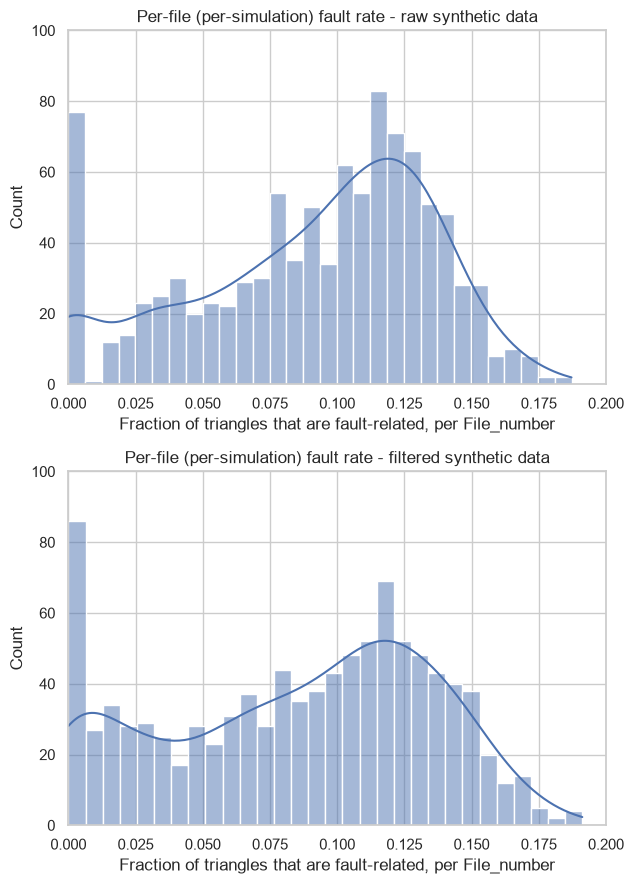

,fault_rate_per_file_raw
count,1000.000000
mean,0.091514
std,0.044541
min,0.000000
25%,0.063745
50%,0.102151
75%,0.125000
max,0.187166


,fault_rate_per_file_filtered
count,1000.000000
mean,0.085411
std,0.049709
min,0.000000
25%,0.046053
50%,0.094595
75%,0.125000
max,0.191176


In [6]:
# This plot addresses the inequality of per-file fault rate on the filtered data.
per_file_fault_rate_raw = (
    raw_df.assign(is_fault=(raw_df["Fault"] == 1).astype(int))
    .groupby("File_number")["is_fault"]
    .mean()
)
per_file_fault_rate_filtered = (
    filtered_df.assign(is_fault=(filtered_df["Fault"] == 1).astype(int))
    .groupby("File_number")["is_fault"]
    .mean()
)

fig, ax = plt.subplots(2, 1, figsize=(6.5, 9))

sns.histplot(per_file_fault_rate_raw, bins=30, kde=True, ax=ax[0])
ax[0].set_title("Per-file (per-simulation) fault rate - raw synthetic data")
ax[0].set_xlabel("Fraction of triangles that are fault-related, per File_number")
ax[0].set_xlim(0, 0.2)
ax[0].set_ylim(0, 100)

sns.histplot(per_file_fault_rate_filtered, bins=30, kde=True, ax=ax[1])
ax[1].set_title("Per-file (per-simulation) fault rate - filtered synthetic data")
ax[1].set_xlabel("Fraction of triangles that are fault-related, per File_number")
ax[1].set_xlim(0, 0.2)
ax[1].set_ylim(0, 100)

plt.tight_layout()

_save_svg(fig, "per_file_fault_rate_raw_and_filtered")
plt.show()

display(per_file_fault_rate_raw.describe().to_frame("fault_rate_per_file_raw"))
display(per_file_fault_rate_filtered.describe().to_frame("fault_rate_per_file_filtered"))

## Build Z with Method 2 (per-file/per-simulation standarization)

In [7]:
z = method2_scale_per_group(sorted_df, feature_cols, group_col="File_number")

# sanity check: each group's mean ~ 0 and population variance ~ 1 by definition.
# Subtract 1 from variance to center it on 0

max_abs_mean = z.groupby(sorted_df["File_number"]).mean().abs().to_numpy().max()
max_abs_var_centered = z.groupby(sorted_df["File_number"]).var(ddof=0).sub(1).abs().to_numpy().max()
print(f"Method 2 sanity check - max |per-file mean|: {max_abs_mean:.2e}, max |per-file var - 1|: {max_abs_var_centered:.2e}")

y = (sorted_df["Fault"] == 1).astype(int).rename("y")
groups = sorted_df["File_number"]

Method 2 sanity check - max |per-file mean|: 1.70e-11, max |per-file var - 1|: 2.22e-15


## Method 2 vs a global scale: observed vs predicted fault counts per surface

**Flow:**
1. `GroupKFold(n_splits=N_SPLITS)` by `File_number`: 
   Here, we use 10-fold cross-validation.
   We train the model on ~900 surfaces and predict the number of fault-related triangles on the remaining
   surfaces (leave-one-group-out cross-validation).
2. Two models:
   - logistic regression (linear),
   - random forest with `min_samples_leaf=0.1*len(y_train)` (non-linear; the averaged leaf fractions estimate the fault
     probability, Malley et al. (2012)). 
     
     *For the random forest, the global scale is the same as no scaling.
3. Per surface: `O` = observed number of fault-related triangles, `E` = expected number (sum of the predicted
   probabilities), error = E - O.

**Comparison (per model)** 
Number of surfaces where **Method 2** has the smaller |error| vs where the global scaling
has the smaller |error|; `scipy.stats.binomtest`, H0: p = 0.5.
Secondary: mean `E` on the surfaces without fault-related triangles (**Method 2** vs global scaling); ROC-AUC.

**Decision rule, alpha = `ALPHA`** (here `ALPHA` = 0.05)
- **Method 2** adds something: **Method 2** closer on most surfaces with p < 0.05 in both models.
- **Method 2** doesn't contribute: the global scale closer on most surfaces with p < 0.05 in both models.
- Different outcome per model: the effect depends on the model.
- Otherwise: lack of evidence to support **Method 2**.

In [8]:
x_raw = sorted_df[feature_cols]

runs = {}
for model in MODEL_LABELS:
    for method in METHOD_LABELS:
        t0 = time.time()
        runs[(model, method)] = grouped_cv_fault_counts_by_scaling_method(
            x_raw,
            y,
            groups,
            method,
            model,
            z_precomputed=z,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE,
        )
        print(f"{model} / {method}: {int(time.time() - t0)}s")

Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
logistic_regression / method3: 2s
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class index: 1
Classifier classes: [0 1]
Selected class: 1
Positive class

In [9]:
# Sanity check: over all surfaces, the expected count should be close to the observed count.
for (model, method), (per_surface, _) in runs.items():
    observed = per_surface["observed_faults"].sum()
    expected = per_surface["expected_faults"].sum()
    print(f"{model} / {method}: observed {observed}, expected {expected:.1f}, expected/observed {expected / observed:.3f}")

logistic_regression / method3: observed 12411, expected 12405.5, expected/observed 1.000
logistic_regression / method2: observed 12411, expected 12405.4, expected/observed 1.000
random_forest / method3: observed 12411, expected 12412.3, expected/observed 1.000
random_forest / method2: observed 12411, expected 12419.1, expected/observed 1.001


### Table 1

In [10]:
fault_free_surfaces = per_file_fault_rate_filtered[per_file_fault_rate_filtered == 0].index

rows = []
for model in MODEL_LABELS:
    global_scale = runs[(model, "method3")][0]
    method2 = runs[(model, "method2")][0]
    assert (global_scale["group_id"].to_numpy() == method2["group_id"].to_numpy()).all()

    error_difference = method2["count_error"].abs().to_numpy() - global_scale["count_error"].abs().to_numpy()
    closer = {"method2": int((error_difference < 0).sum()), "method3": int((error_difference > 0).sum())}
    n_ties = int((error_difference == 0).sum())
    binomtest_p = binomtest(closer["method2"], closer["method2"] + closer["method3"], 0.5).pvalue

    for method in METHOD_LABELS:
        per_surface, probabilities = runs[(model, method)]
        q1, median, q3 = per_surface["count_error"].abs().quantile([0.25, 0.5, 0.75])
        rows.append(
            {
                "model": MODEL_LABELS[model],
                "scaling": METHOD_LABELS[method],
                "median_count_error_abs": median,
                "count_error_abs_q1": q1,
                "count_error_abs_q3": q3,
                "surfaces_closer": closer[method],
                "ties": n_ties,
                "binomtest_p": binomtest_p,
                "mean_expected_on_fault_free": per_surface.loc[
                    per_surface["group_id"].isin(fault_free_surfaces), "expected_faults"
                ].mean(),
                "roc_auc": roc_auc_score(y, probabilities),
            }
        )

table_1 = pd.DataFrame(rows)
table_1.to_csv(FIG_OUT_DIR / "table_1_method2_vs_global_scale.csv", index=False)

print(f"Surfaces without fault-related triangles: {len(fault_free_surfaces)}")
display(table_1.round({"median_count_error_abs": 2, "count_error_abs_q1": 2, "count_error_abs_q3": 2, "mean_expected_on_fault_free": 2, "roc_auc": 4}))

Surfaces without fault-related triangles: 86


,model,scaling,median_count_error_abs,count_error_abs_q1,count_error_abs_q3,surfaces_closer,ties,binomtest_p,mean_expected_on_fault_free,roc_auc
0,Logistic regression,global scale,2.03,0.85,4.37,590,0,1.384527e-08,2.56,0.9848
1,Logistic regression,Method 2,3.21,1.41,5.95,410,0,1.384527e-08,7.76,0.9695
2,Random forest,global scale,4.07,2.20,6.67,684,0,7.801358e-32,6.24,0.9667
3,Random forest,Method 2,6.10,3.15,9.45,316,0,7.801358e-32,18.00,0.9677


In [11]:
# Decision rule in-code.
for model in MODEL_LABELS:
    model_rows = table_1[table_1["model"] == MODEL_LABELS[model]].set_index("scaling")
    closer_method2 = model_rows.loc["Method 2", "surfaces_closer"]
    closer_global_scale = model_rows.loc["global scale", "surfaces_closer"]
    p_value = model_rows.loc["Method 2", "binomtest_p"]
    if p_value >= ALPHA:
        outcome = "no evidence of a difference"
    elif closer_method2 > closer_global_scale:
        outcome = "Method 2 closer"
    else:
        outcome = "global scale closer"
    print(f"{MODEL_LABELS[model]}: Method 2 closer on {closer_method2}, global scale closer on {closer_global_scale}, p = {p_value:.3g} -> {outcome}")

Logistic regression: Method 2 closer on 410, global scale closer on 590, p = 1.38e-08 -> global scale closer
Random forest: Method 2 closer on 316, global scale closer on 684, p = 7.8e-32 -> global scale closer


In [12]:
per_surface_all = runs[("logistic_regression", "method3")][0][["group_id", "n", "observed_faults"]].copy()
for (model, method), (per_surface, _) in runs.items():
    per_surface_all[f"expected_{model}_{method}"] = per_surface["expected_faults"].to_numpy()
    per_surface_all[f"count_error_{model}_{method}"] = per_surface["count_error"].to_numpy()
per_surface_all.to_csv(FIG_OUT_DIR / "per_surface_observed_vs_expected.csv", index=False)
per_surface_all.head()

,group_id,n,observed_faults,expected_logistic_regression_method3,count_error_logistic_regression_method3,expected_logistic_regression_method2,count_error_logistic_regression_method2,expected_random_forest_method3,count_error_random_forest_method3,expected_random_forest_method2,count_error_random_forest_method2
0,0,156,13,17.116791,4.116791,14.689016,1.689016,15.726162,2.726162,9.512492,-3.487508
1,1,145,1,5.954957,4.954957,8.704610,7.704610,10.759097,9.759097,15.183890,14.183890
2,2,147,18,4.389902,-13.610098,12.216718,-5.783282,9.248069,-8.751931,17.169708,-0.830292
3,3,147,13,13.412927,0.412927,13.373945,0.373945,10.745029,-2.254971,8.210617,-4.789383
4,4,142,8,9.975388,1.975388,11.051036,3.051036,10.808771,2.808771,9.241663,1.241663


### Fig. 1

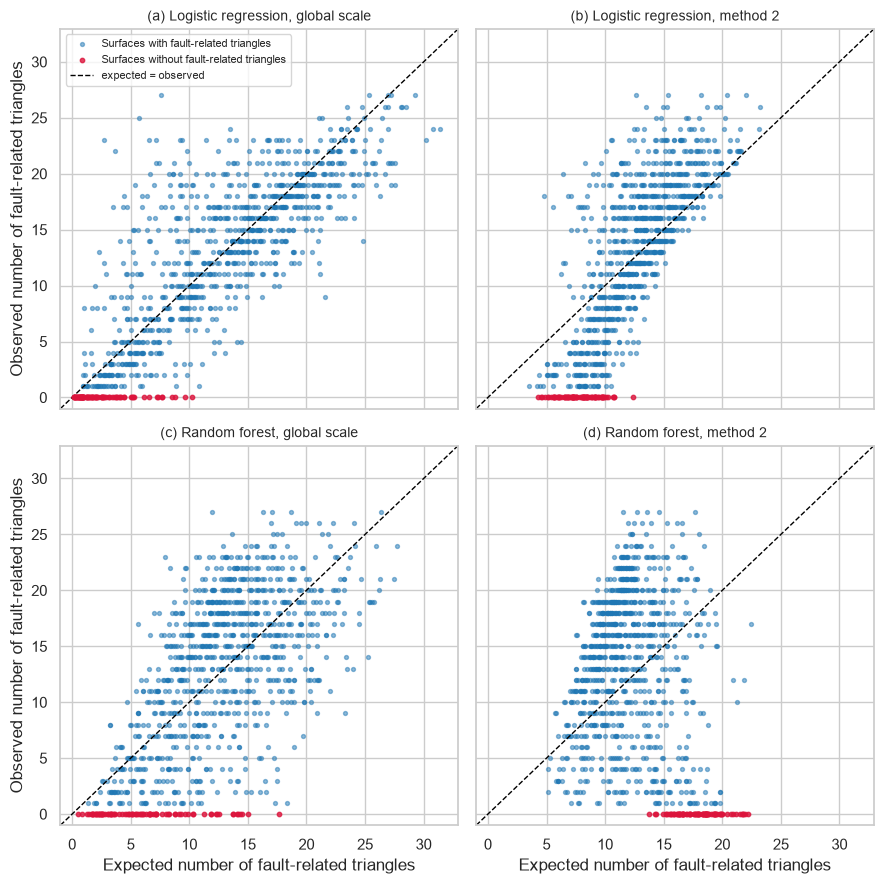

In [13]:
axis_max = 1.05 * max(
    max(per_surface["observed_faults"].max(), per_surface["expected_faults"].max())
    for per_surface, _ in runs.values()
)
panel_letters = iter("abcd")

fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True, sharey=True)
for row, model in enumerate(MODEL_LABELS):
    for col, method in enumerate(METHOD_LABELS):
        ax = axes[row, col]
        per_surface = runs[(model, method)][0]
        is_fault_free = per_surface["group_id"].isin(fault_free_surfaces)

        ax.scatter(
            per_surface.loc[~is_fault_free, "expected_faults"],
            per_surface.loc[~is_fault_free, "observed_faults"],
            s=8,
            alpha=0.5,
            color="tab:blue",
            label="Surfaces with fault-related triangles",
        )
        ax.scatter(
            per_surface.loc[is_fault_free, "expected_faults"],
            per_surface.loc[is_fault_free, "observed_faults"],
            s=10,
            alpha=0.8,
            color="crimson",
            zorder=3,
            label="Surfaces without fault-related triangles",
        )
        ax.plot([-1, axis_max], [-1, axis_max], color="black", linestyle="--", linewidth=1, label="expected = observed")
        ax.set_xlim(-1, axis_max)
        ax.set_ylim(-1, axis_max)
        ax.set_title(f"({next(panel_letters)}) {MODEL_LABELS[model]}, {METHOD_LABELS[method].lower()}", fontsize=10)
        if row == 1:
            ax.set_xlabel("Expected number of fault-related triangles")
        if col == 0:
            ax.set_ylabel("Observed number of fault-related triangles")

axes[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout()

_save_svg(fig, "fig_1_observed_vs_expected_fault_counts")
plt.show()

## Post-hoc analysis

- **Thresholds (Table 2):** **Method 2** vs the global scale; subsets of surfaces selected by fraction of the fault-related triangles.
  - All surfaces with faults
  - Surfaces at or above the 25th, 50th, 75th and 90th percentile of the fault proportion.
  - Lowest quartile.
- **Mechanism (Fig. 2):**
  - Panel (a): Spearman correlation between the per-surface mean / standard deviation of each feature and the
  fraction of fault-related triangles on the surface.
  - Panel (b): mean `E - O` in bins of the fault proportion.

### Table 2

In [15]:
QUANTILES = (0.25, 0.5, 0.75, 0.9)

fault_fraction = per_file_fault_rate_filtered
with_faults = fault_fraction[fault_fraction > 0]

subsets = {"all surfaces with faults": with_faults.index}
for q in QUANTILES:
    threshold = with_faults.quantile(q)
    subsets[f"Fault related triangles fraction >= q{int(q * 100)} ({threshold:.3f})"] = with_faults[with_faults >= threshold].index
lowest_threshold = with_faults.quantile(0.25)
subsets[f"Lowest quartile (<= {lowest_threshold:.3f})"] = with_faults[with_faults <= lowest_threshold].index

rows = []
for subset_label, surfaces in subsets.items():
    for model in MODEL_LABELS:
        global_scale = runs[(model, "method3")][0].set_index("group_id").loc[surfaces]
        per_surface_scaled = runs[(model, "method2")][0].set_index("group_id").loc[surfaces]
        error_difference = per_surface_scaled["count_error"].abs() - global_scale["count_error"].abs()
        closer_method2 = int((error_difference < 0).sum())
        closer_global_scale = int((error_difference > 0).sum())
        rows.append(
            {
                "subset": subset_label,
                "model": MODEL_LABELS[model],
                "n_surfaces": len(surfaces),
                "method2_closer": closer_method2,
                "global_scale_closer": closer_global_scale,
                "binomtest_p": binomtest(closer_method2, closer_method2 + closer_global_scale, 0.5).pvalue,
                "median_count_error_abs_global_scale": global_scale["count_error"].abs().median(),
                "median_count_error_abs_method2": per_surface_scaled["count_error"].abs().median(),
                "mean_count_error_global_scale": global_scale["count_error"].mean(),
                "mean_count_error_method2": per_surface_scaled["count_error"].mean(),
            }
        )

table_2 = pd.DataFrame(rows)
table_2.to_csv(FIG_OUT_DIR / "table_2_fault_fraction_thresholds.csv", index=False)

display(
    table_2.round(
        {
            "median_count_error_abs_global_scale": 2,
            "median_count_error_abs_method2": 2,
            "mean_count_error_global_scale": 2,
            "mean_count_error_method2": 2,
        }
    )
)

,subset,model,n_surfaces,method2_closer,global_scale_closer,binomtest_p,median_count_error_abs_global_scale,median_count_error_abs_method2,mean_count_error_global_scale,mean_count_error_method2
0,all surfaces with faults,Logistic regression,914,407,507,1.047143e-03,2.06,2.92,-0.25,-0.74
1,all surfaces with faults,Random forest,914,315,599,3.820654e-21,3.96,5.59,-0.59,-1.68
2,Fault related triangles fraction >= q25 (0.062),Logistic regression,685,358,327,2.516774e-01,2.24,2.21,-0.86,-2.48
3,Fault related triangles fraction >= q25 (0.062),Random forest,685,243,442,2.564985e-14,4.10,5.25,-2.14,-4.66
4,Fault related triangles fraction >= q50 (0.101),Logistic regression,459,213,246,1.351846e-01,2.55,3.49,-1.51,-3.88
5,Fault related triangles fraction >= q50 (0.101),Random forest,459,117,342,1.247007e-26,4.73,6.96,-3.71,-6.66
6,Fault related triangles fraction >= q75 (0.127),Logistic regression,233,89,144,3.815657e-04,2.61,4.81,-2.03,-5.21
7,Fault related triangles fraction >= q75 (0.127),Random forest,233,44,189,1.345470e-22,6.13,8.63,-5.02,-8.52
8,Fault related triangles fraction >= q90 (0.147),Logistic regression,94,25,69,6.339265e-06,2.38,6.56,-2.89,-6.62
9,Fault related triangles fraction >= q90 (0.147),Random forest,94,15,79,1.150544e-11,6.97,10.23,-6.49,-10.00


### Mechanism

In [18]:
surface_means = sorted_df.groupby("File_number")[feature_cols].mean()
surface_stds = sorted_df.groupby("File_number")[feature_cols].std(ddof=0)
fraction_aligned = fault_fraction.loc[surface_means.index]

mechanism = pd.DataFrame(
    {
        "feature": feature_cols,
        "spearman_corr_mean_vs_fault_fraction": [spearmanr(surface_means[f], fraction_aligned).statistic for f in feature_cols],
        "spearman_corr_std_vs_fault_fraction": [spearmanr(surface_stds[f], fraction_aligned).statistic for f in feature_cols],
    }
)
mechanism["max_abs_spearman_corr"] = mechanism[["spearman_corr_mean_vs_fault_fraction", "spearman_corr_std_vs_fault_fraction"]].abs().max(axis=1)
mechanism = mechanism.sort_values("max_abs_spearman_corr", ascending=False).reset_index(drop=True)
mechanism.to_csv(FIG_OUT_DIR / "mechanism_feature_stats_vs_fault_fraction.csv", index=False)

n_dependent = int((mechanism["max_abs_spearman_corr"] >= 0.5).sum())
print(f"Features with |spearman_corr| >= 0.5 (per-surface mean or standard deviation): {n_dependent} of {len(feature_cols)}")
display(mechanism.round(2))

Features with |spearman_corr| >= 0.5 (per-surface mean or standard deviation): 20 of 24


,feature,spearman_corr_mean_vs_fault_fraction,spearman_corr_std_vs_fault_fraction,max_abs_spearman_corr
0,Angle_D_Intermediate,0.73,0.60,0.73
1,Angle_D_Max,0.70,0.58,0.70
2,Angle_D_Min,0.70,0.54,0.70
3,Euclidean_D_Intermediate,0.69,0.50,0.69
4,Euclidean_D_Min,0.66,0.48,0.66
5,Euclidean_D_Max,0.64,0.45,0.64
6,Euclidean_N_Intermediate,0.60,0.53,0.60
7,Angle_N_Intermediate,0.60,0.53,0.60
8,Y_N,-0.01,0.59,0.59
9,Cosine_D_Intermediate,0.57,0.40,0.57


### Fig. 2

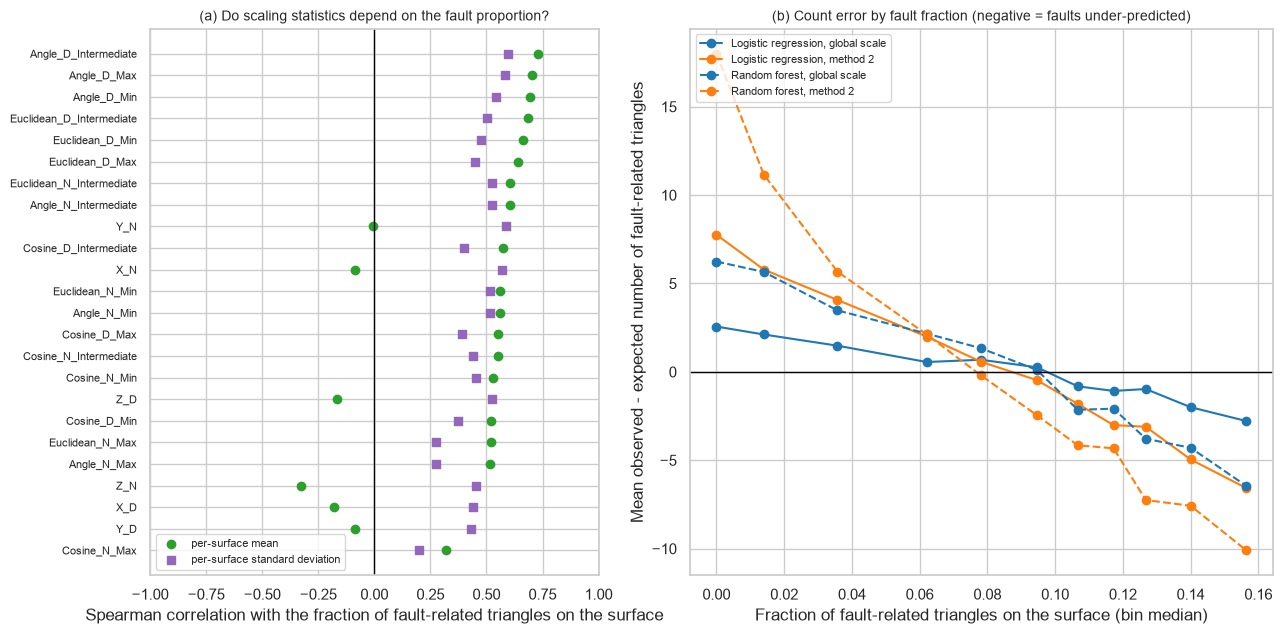

In [ ]:
# Bin 0: surfaces without fault-related triangles; bins 1-10: deciles of the fraction of the fault-related triangles.
decile = pd.qcut(with_faults, 10, labels=False) + 1
fraction_bin = pd.Series(0, index=fault_fraction.index).add(decile, fill_value=0).astype(int)
bin_centre = fault_fraction.groupby(fraction_bin).median()

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5), gridspec_kw={"width_ratios": [1, 1.3]})

positions = np.arange(len(mechanism))[::-1]
ax[0].scatter(mechanism["spearman_corr_mean_vs_fault_fraction"], positions, marker="o", color="tab:green", label="per-surface mean")
ax[0].scatter(
    mechanism["spearman_corr_std_vs_fault_fraction"], positions, marker="s", color="tab:purple", label="per-surface standard deviation"
)
ax[0].axvline(0, color="black", linewidth=1)
ax[0].set_yticks(positions)
ax[0].set_yticklabels(mechanism["feature"], fontsize=8)
ax[0].set_xlim(-1, 1)
ax[0].set_xlabel("Spearman correlation with the fraction of fault-related triangles on the surface")
ax[0].set_title("(a) Do scaling statistics depend on the fault proportion?", fontsize=10)
ax[0].legend(fontsize=8, loc="lower left")

for model, linestyle in zip(MODEL_LABELS, ["-", "--"]):
    for method, color in zip(METHOD_LABELS, ["tab:blue", "tab:orange"]):
        per_surface = runs[(model, method)][0].set_index("group_id")
        count_error = per_surface["count_error"].loc[fraction_bin.index]
        mean_by_bin = count_error.groupby(fraction_bin).mean()
        ax[1].plot(
            bin_centre,
            mean_by_bin.loc[bin_centre.index],
            marker="o",
            linestyle=linestyle,
            color=color,
            label=f"{MODEL_LABELS[model]}, {METHOD_LABELS[method].lower()}",
        )
ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_xlabel("Fraction of fault-related triangles on the surface (bin median)")
ax[1].set_ylabel("Mean observed - expected number of fault-related triangles")
ax[1].set_title("(b) Count error by fault fraction (negative = faults under-predicted)", fontsize=10)
ax[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()

_save_svg(fig, "fig_2_mechanism_and_count_bias")
plt.show()